<a href="https://colab.research.google.com/github/itsahegde/msis-labs/blob/main/aps-lab/aps_lab_aug_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
from sklearn.datasets import load_breast_cancer

In [39]:
data = load_breast_cancer()

In [40]:
x = data.data

In [41]:
y = data.target

In [42]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [43]:
data.DESCR

'.. _breast_cancer_dataset:\n\nBreast cancer Wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [45]:
x = pd.DataFrame(data.data, columns=data.feature_names)

In [46]:
y = pd.Series((data.target==0).astype(int), name="malignant")

In [47]:
x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [48]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: malignant, Length: 569, dtype: int64

In [49]:
print(y.value_counts())

malignant
0    357
1    212
Name: count, dtype: int64


In [50]:
print("Feature matrix shape:", x.shape)
print("Target shape:", y.shape)
print("Class names:", data.target_names)

Feature matrix shape: (569, 30)
Target shape: (569,)
Class names: ['malignant' 'benign']


In [51]:
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({"Class": data.target_names, "Count": class_counts.values, "Probability": class_counts.values/len(y)})

In [52]:
print(class_distribution)

       Class  Count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


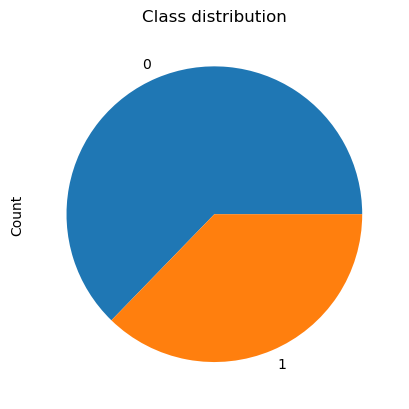

In [53]:
class_distribution.plot(
    x="Class",
    y="Count",
    kind="pie",
    legend=False,
    color=["tomato", "blue"]
)

# plt.ylabel("Number of observations")
plt.title("Class distribution")
# plt.xticks(rotation=0)
plt.show()

In [54]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training size", len(x_train))
print("Test size", len(x_test))

print("Training proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("Testing proportions:")
print(y_test.value_counts(normalize=True).sort_index())

Training size 455
Test size 114
Training proportions:
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Testing proportions:
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [55]:
from sklearn.pipeline import make_pipeline

In [56]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(x_train, y_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [57]:
y_preds = model.predict(x_test)

In [58]:
probs = model.predict_proba(x_test)
print(probs[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [59]:
print(probs[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [60]:
results = pd.DataFrame({
    "Actual_Class": y_test.values,
    "p_malignant": probs[:, 0],
    "p_benign": probs[:, 1]
})

print(results.head(10))

   Actual_Class   p_malignant  p_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [61]:
results["Actual_label"] = results["Actual_Class"].map({
    0: "Malignant",
    1: "Benign"
})

print(
    results[
        ["Actual_label", "p_malignant", "p_benign"]
    ].head(10)
)

  Actual_label   p_malignant  p_benign
0    Malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    Malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    Malignant  4.908445e-01  0.509155
5    Malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    Malignant  9.989878e-01  0.001012
8    Malignant  9.994313e-01  0.000569
9    Malignant  9.892324e-01  0.010768


In [62]:
threshold = 0.50

results["Predicted_malignant"] = (
    results["p_malignant"]>=threshold
).astype(int)

results["Predicted_label"] = results[
    "Predicted_malignant"
].map({
    1: "Malignant",
    0: "Benign"
})

In [63]:
print(
    results[
        [
            "Actual_label",
            "p_malignant",
            "Predicted_label"
        ]
    ].head(10)
)

  Actual_label   p_malignant Predicted_label
0    Malignant  9.996354e-01       Malignant
1       Benign  1.074660e-08          Benign
2    Malignant  9.574321e-01       Malignant
3       Benign  4.238127e-01          Benign
4    Malignant  4.908445e-01          Benign
5    Malignant  9.993840e-01       Malignant
6       Benign  2.384659e-01          Benign
7    Malignant  9.989878e-01       Malignant
8    Malignant  9.994313e-01       Malignant
9    Malignant  9.892324e-01       Malignant


In [64]:
for threshold in [0.30, 0.50, 0.70]:
    predictions = (
        results["p_malignant"]>=threshold
    ).astype(int)
    print(
        f"Threshold = {threshold}: "
        f"Predicted malignant cases = {predictions.sum()}"
    )

Threshold = 0.3: Predicted malignant cases = 76
Threshold = 0.5: Predicted malignant cases = 74
Threshold = 0.7: Predicted malignant cases = 72


In [65]:
from sklearn.metrics import confusion_matrix

In [66]:
actual_malignant = (y_test.values==0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
    predicted_malignant = (
        probs[:, 0]>=threshold
    ).astype(int)

    cm = confusion_matrix(
        actual_malignant,
        predicted_malignant
    )

    print(f"\nThreshold = {threshold}")
    print(cm)


Threshold = 0.3
[[38  4]
 [ 0 72]]

Threshold = 0.5
[[39  3]
 [ 1 71]]

Threshold = 0.7
[[41  1]
 [ 1 71]]


In [67]:
# Accuracy = tp + tn / tp + tn + fp + fn WHAT PROPORTION OF ALL TUMOR PREDS ARE CORRECT 

In [68]:
# PRECISION = TP/TP +FP AMONG ALL THE TUMORS PREDICTED AS MALIGNANT, HOW MANY WERE ACTUALLY MALIGNANT

In [69]:
# RECALL = SENSITIVITY = TP/TP+FN AMONG ALL THE PATIENTS WHO ACTUALLY HAD MALIGNANT TUMORS HOW MANY WERE DETECTED

In [70]:
#SPECIFICITY = TN/TN+FP AMONG ALL THE PATIENTS WHO ACTUALLY HAD BENIGN TUMORS HOW MANY WERE DETECTED

In [71]:
#F1 = 2(PRECISION * RECALL/PRECISION+RECALL)

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [73]:
print("Accuracy, Precision, Recall, f1_score")

Accuracy, Precision, Recall, f1_score


In [75]:
print(accuracy_score(y_test, y_preds))

0.9649122807017544


In [76]:
print(precision_score(y_test, y_preds))

0.975


In [77]:
print(recall_score(y_test, y_preds))

0.9285714285714286


In [78]:
print(f1_score(y_test, y_preds))

0.9512195121951219


In [79]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

In [85]:
cm = confusion_matrix(y_test, y_preds)


In [86]:
cm

array([[71,  1],
       [ 3, 39]])

In [87]:
l1, l2 = confusion_matrix(y_test, y_preds)

In [89]:
tp, fn = l1[0], l1[1]

In [90]:
fp, tn = l2[0], l2[1]

In [91]:
print(tp, fn, fp, tn)

71 1 3 39


In [94]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pipeline = make_pipeline(StandardScaler(), LogisticRegression())
pipeline.fit(x_train, y_train)
y_probs = pipeline.predict_proba(x_test)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.1)

metrics_data = []

for t in thresholds:

    y_pred = (y_probs >= t).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    metrics_data.append({
        'Threshold': round(t, 2),
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

threshold_df = pd.DataFrame(metrics_data)
print(threshold_df)

   Threshold  Accuracy  Precision  Recall  F1-Score  TP  TN  FP  FN
0        0.1    0.9474     0.8913  0.9762    0.9318  41  67   5   1
1        0.2    0.9561     0.9111  0.9762    0.9425  41  68   4   1
2        0.3    0.9825     0.9762  0.9762    0.9762  41  71   1   1
3        0.4    0.9737     0.9756  0.9524    0.9639  40  71   1   2
4        0.5    0.9649     0.9750  0.9286    0.9512  39  71   1   3
5        0.6    0.9649     1.0000  0.9048    0.9500  38  72   0   4
6        0.7    0.9649     1.0000  0.9048    0.9500  38  72   0   4
7        0.8    0.9474     1.0000  0.8571    0.9231  36  72   0   6
8        0.9    0.9211     1.0000  0.7857    0.8800  33  72   0   9
